In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pathlib import Path

In [2]:
import cartopy
cartopy.config['data_dir'] = '/g/data/xp65/public/apps/cartopy-data'
cartopy.config['pre_existing_data_dir'] = '/g/data/xp65/public/apps/cartopy-data'
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [12]:
nc_files

[PosixPath('/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_Qld/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/ACCESS-ESM1-5/r20i1p1f1/CCAMoc-v2112/ACCESS-ESM1-5_r20i1p1f1_CCAMoc-v2112_domain_AUS-10idrought_metrics_perc_15_historical_1960_2014.nc'),
 PosixPath('/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_Qld/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/ACCESS-ESM1-5/r40i1p1f1/CCAMoc-v2112/ACCESS-ESM1-5_r40i1p1f1_CCAMoc-v2112_domain_AUS-10idrought_metrics_perc_15_historical_1960_2014.nc'),
 PosixPath('/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_Qld/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/ACCESS-ESM1-5/r6i1p1f1/CCAM-v2105/ACCESS-ESM1-5_r6i1p1f1_CCAM-v2105_domain_AUS-10idrought_metrics_perc_15_historical_1960_2014.nc')]

In [13]:
# --- Config ---
base = "/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics"
dataset = "CORDEX_CSIRO"           # ['BARPA', 'CMIP6', 'CORDEX_CSIRO', 'CORDEX_Qld', 'NARCLIM']
experiment = "historical"   # ['historical', 'ssp126', 'ssp370', 'ssp585']
variable = "pr"             # ['mrro', 'mrso', 'pr']
drought_threshold = 'Perc_15'
baseline = 'Baseline_1970_2005'
scale = "Scale_3"           # ['Scale_3', 'Scale_12']

# --- Build path ---
path = Path(base) / dataset / experiment / variable / drought_threshold / baseline / scale

# --- Load all models ---
datasets = {}
for model_dir in sorted(path.iterdir()):
    print(model_dir)
    if not model_dir.is_dir():
        continue

    nc_files = list(model_dir.rglob("*.nc"))

    if not nc_files:
        print(f"Warning: no .nc file found in {model_dir.name}")
        continue

    datasets[model_dir.name] = xr.open_mfdataset(nc_files, combine="by_coords")
    print(f"Loaded: {model_dir.name}")

# --- Example access ---
# datasets["CESM2"]
# datasets["EC-Earth3"]

/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_CSIRO/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/ACCESS-CM2
Loaded: ACCESS-CM2
/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_CSIRO/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/ACCESS-ESM1-5
Loaded: ACCESS-ESM1-5
/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_CSIRO/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/CESM2
Loaded: CESM2
/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_CSIRO/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/CMCC-ESM2
Loaded: CMCC-ESM2
/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_CSIRO/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/CNRM-ESM2-1
Loaded: CNRM-ESM2-1
/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_CSIRO/historical/pr/Perc_15/Baseline_1970_2005/Scale_3/EC-Earth3
Loaded: EC-Earth3
/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics/CORDEX_CSIRO/historical/pr/Perc_15/Baseline_1970_2005/S

In [14]:
if experiment == "historical":
    time_min = "1960"; time_max = "2014"
else:
    time_min = "2015"; time_max = "2100"

In [15]:
for name, ds in datasets.items():
    cal = ds.time.encoding.get("calendar", ds.time.dt.calendar)
    if cal != "proleptic_gregorian":
        datasets[name] = ds.sel(time=slice(time_min, time_max)).convert_calendar("standard")
    else:
        datasets[name] = ds.sel(time=slice(time_min, time_max))

In [16]:
# Determine the time under drought, i.e. the proportion of time that is under drought for each of the driving models
time_under_drought = {}
for name, ds in datasets.items():
    time_under_drought[name] = ds.timing.sum(dim="time", min_count=1) / len(ds.timing.time)

In [17]:
time_under_drought_all = xr.concat(list(time_under_drought.values()),dim="forcing_gcm"
                               ).assign_coords(forcing_gcm=list(time_under_drought.keys()))

/scratch/dt6/cb6525/tmp/ipykernel_4133057/1238542278.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  time_under_drought_all = xr.concat(list(time_under_drought.values()),dim="forcing_gcm"
/scratch/dt6/cb6525/tmp/ipykernel_4133057/1238542278.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  time_under_drought_all = xr.concat(list(time_under_drought.values()

In [18]:
time_under_drought_all

<xarray.DataArray 'timing' (forcing_gcm: 7, lat: 625, lon: 757)> Size: 26MB
dask.array<concatenate, shape=(7, 625, 757), dtype=float64, chunksize=(1, 17, 21), chunktype=numpy.ndarray>
Coordinates:
  * forcing_gcm  (forcing_gcm) <U13 364B 'ACCESS-CM2' ... 'NorESM2-MM'
  * lat          (lat) float64 5kB -44.0 -43.9 -43.9 -43.8 ... -10.1 -10.1 -10.0
  * lon          (lon) float64 6kB 112.0 112.1 112.1 112.2 ... 153.9 153.9 154.0
Attributes:
    long_name:  drought event timing (binary drought/non-drought index)

In [19]:
time_under_drought_all_mmm = time_under_drought_all.mean(dim="forcing_gcm")

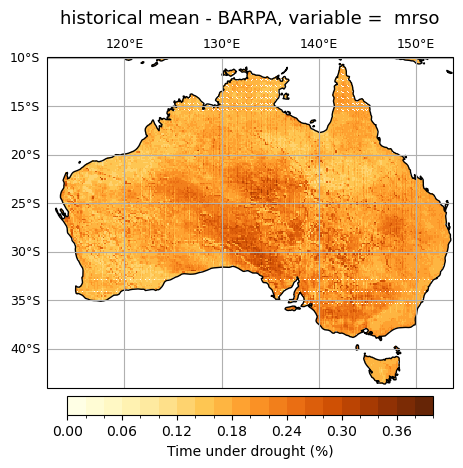

In [10]:
ax = plt.subplot(projection=ccrs.PlateCarree())
time_under_drought_all_mmm.plot.pcolormesh(x="lon", y="lat", ax=ax, cmap="YlOrBr",levels= np.linspace(0,.4,21),
                                           cbar_kwargs={
                                               "label": "Time under drought (%)",
                                               "shrink":0.6,
                                               "pad": 0.02,
                                               "location":"bottom", 
                                           }, add_colorbar=True)
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.bottom_labels = False
gl.right_labels = False
ax.set_title(f"{experiment} mean - {dataset}, variable =  {variable}", fontsize=13, pad=10)

gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

plt.tight_layout()

plt.savefig(f"/g/data/dt6/cb6525/graphs/time_under_drought/{experiment}_{dataset}_time_under_drought_{variable}.png", dpi=300, bbox_inches="tight")